# Price Exploratory Data Analysis

This exploratory data analysis focuses on price in the AirBnB Listings. The aim is to gain insight.

In [14]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
# Load the processed listings data
df = pd.read_csv("../data/processed/processed_listings.csv")

In [16]:
# Basic statistics for price
df["price"].describe()

count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [17]:
# Calculate the luxury listings based on price
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

luxury_listing = df[df["price"] >= upper_bound]

In [18]:
# Total luxury listings
total_luxury = len(luxury_listing)
total_luxury

2977

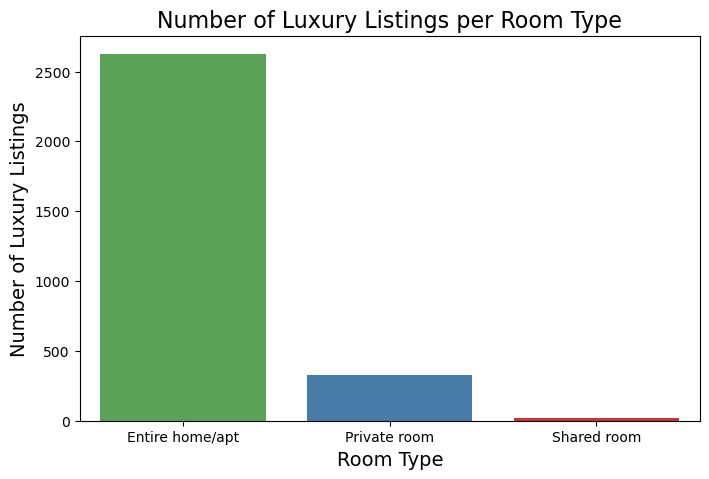

In [19]:
# 
luxury_counts = luxury_listing["room_type"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=luxury_counts.index, y=luxury_counts.values, palette="Set1", hue=luxury_counts.values, legend=False)
plt.title("Number of Luxury Listings per Room Type", fontsize=16)
plt.xlabel("Room Type", fontsize=14)
plt.ylabel("Number of Luxury Listings", fontsize=14)
plt.savefig("../outputs/luxury_listings_by_room_type.png", dpi=150, bbox_inches="tight")
plt.show()

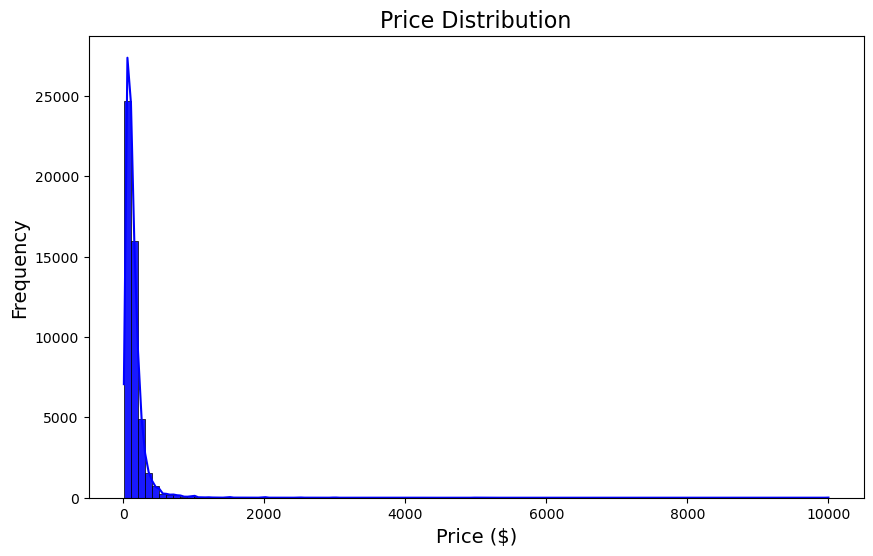

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df["price"], bins=100, color="blue", kde=True, alpha=0.9)
plt.title("Price Distribution", fontsize=16)
plt.xlabel("Price ($)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.savefig("../outputs/price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary of Price EDA

This exploratory data analysis (EDA) focused on the pricing aspects of Airbnb listings in New York City, examining price distributions, outliers, and luxury segments.

- **Price Statistics**: Prices range from $10 to $10,000, with an average of $153 and a median of $106. The data shows high variability (std dev $240).
- **Luxury Listings**: Defined as prices above the upper outlier bound ($334, using 1.5*IQR), there are 2,977 luxury listings.
- **Luxury by Room Type**: Entire homes/apartments dominate luxury listings, followed by private rooms.
- **Price Distribution**: The histogram reveals a right-skewed distribution with most listings under $500, and a long tail of high-priced outliers.

These insights indicate a wide price range, with luxury options concentrated in certain room types.